# Homework 2.1

 <a name="I"></a>
### I. Import Packages and Create Model Object

In [1]:
#import packages
import flopy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mp

#jupyter specific--included to show plots in notebook
%matplotlib inline 

<strong> Note: You will have to modify the exe_name variable to direct flopy to the modflow executable file on your computer!</strong>

In [2]:
#create model object
modelname = "my_pumping_model"
m = flopy.modflow.Modflow(modelname, exe_name = 'mf2005')

c:\Users\gieki\AppData\Local\Programs\Python\Python313\Lib\site-packages\flopy\mbase.py:104: UserWarning: The program mf2005 does not exist or is not executable.
  warn(


 <a name="II"></a>
### II. Discretize Model and Attach DIS Package

In [3]:
#assign discretization variables
Lx = 100.
Ly = 100.
ztop = 0.
zbot = -50.
nlay = 1
nrow = 25
ncol = 25
dx = Lx/ncol
dy = Ly/nrow
dz = (ztop - zbot) / nlay

#specify number of stress periods
nper = 1

#specify if stress period is transient or steady-state
steady = [True]

#create flopy discretization object, length and time are meters (2) and days (4)
dis = flopy.modflow.ModflowDis(model=m, nlay=nlay, nrow=nrow, ncol=ncol, 
                               delr=dx, delc=dy, top=ztop, botm=zbot, 
                               itmuni = 4, lenuni = 2, 
                               nper=nper, steady=steady)

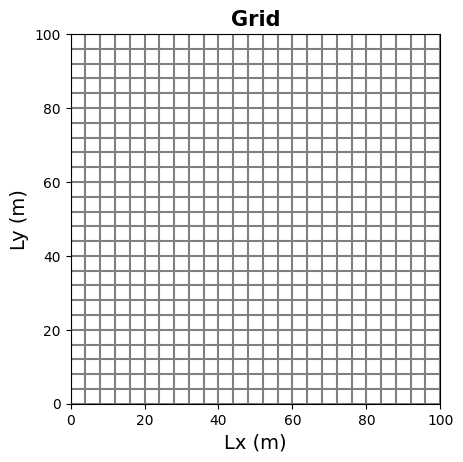

In [4]:
#CHECK GRID
modelmap = flopy.plot.PlotMapView(model=m, layer=0)
grid = modelmap.plot_grid() 
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Grid', fontsize = 15, fontweight = 'bold')
plt.show()

 <a name="III"></a>
### III. Assign Cell Activity/Starting Heads and Attach BAS Package

In [5]:
#create ibound as array of ints = 1
ibound = np.ones((nlay, nrow, ncol), dtype=np.int32)
#assign left and right boundary cells to constant head
ibound[:, :, 0] = -1
ibound[:, :, -1] = -1
ibound[:,0,:] = -1
ibound[:,-1,:] = -1

#create strt as array of floats = 10m
strt = np.ones((nlay, nrow, ncol), dtype=np.float32)
strt[:, :, 0] = 10.
strt[:, :, -1] = 10.
strt[:, 0, :] = 10.
strt[:, -1, :] = 10.

#create flopy bas object
bas = flopy.modflow.ModflowBas(m, ibound=ibound, strt=strt)

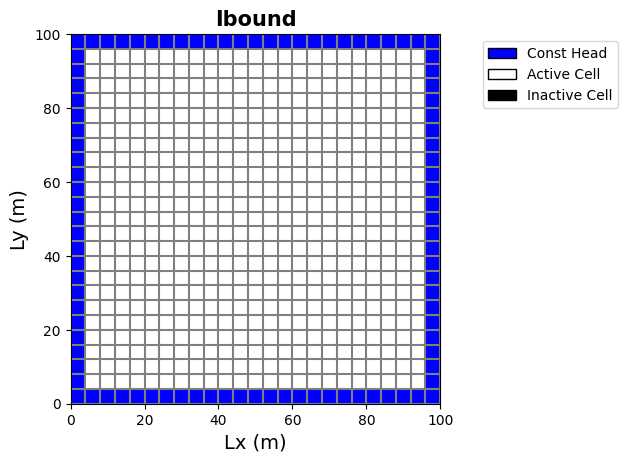

In [6]:
#CHECK IBOUND
#use flopy to plot grid and ibound
modelmap = flopy.plot.PlotMapView(model=m, layer=0)
grid = modelmap.plot_grid()
ib = modelmap.plot_ibound()
#add labels and legend
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Ibound', fontsize = 15, fontweight = 'bold')
plt.legend(handles=[mp.patches.Patch(color='blue',label='Const Head',ec='black'),
                   mp.patches.Patch(color='white',label='Active Cell',ec='black'),
                   mp.patches.Patch(color='black',label='Inactive Cell',ec='black')],
                   bbox_to_anchor=(1.5,1.0))
plt.show(modelmap)

 <a name="IV"></a>
### IV. Define Layer Properties and Attach LPF Package

In [7]:
#define horizontal and vertical hydraulic conductivity
#hk = np.ones((nlay,nrow,ncol), dtype=np.float32)
# 1. Define a base value (e.g., Permeable Sand) for the entire grid
# np.ones creates a matrix of 1s, we multiply by 20 to get hk=20 everywhere
hk = np.ones((nrow, ncol)) * 3.0
hk[:, int(ncol/2):] = 1.0
vk = np.ones((nlay,nrow,ncol), dtype=np.float32)

#define specific storage
ss = np.ones((nlay,nrow,ncol), dtype=float)
ss[:,:,:] = 1e-5

#define layer type as confined
laytyp = np.zeros((nlay,), dtype=np.int32)

#create flopy layer property flow object
lpf = flopy.modflow.ModflowLpf(model=m, hk=hk, vka=vk, ss=ss, laytyp=laytyp, ipakcb=1)


In [8]:
#perm = loadmat('perm')['perm']
#print(hk.shape)
#hk[:,0:24,0:24]=perm[0:24,0:24]
#togliere vk

 <a name="V"></a>
# V. Create Wells and Attach MODFLOW WEL Package

For this model, we will create a single well at the center of the domain:                     

In [9]:
#well 1
#Create Single Well at center of domain with [lay, row, col, flux] list
pumping_rate_1 = -75 #in m^3/d, negative for pumping/positive for injection
rowwell_1=20
colwell_1=17
well_1 = [0,rowwell_1,colwell_1,pumping_rate_1]
print("Well 1 [layer, row, column, flux]: \n", well_1)



#well 2
pumping_rate_2 = -40 #in m^3/d, negative for pumping/positive for injection
rowwell_2=9
colwell_2=19
well_2 = [0,rowwell_2,colwell_2,pumping_rate_2]
print("Well 2 [layer, row, column, flux]: \n", well_2)



#well 3
pumping_rate_3 = -60 #in m^3/d, negative for pumping/positive for injection
rowwell_3=15
colwell_3=3
well_3 = [0,rowwell_3,colwell_3,pumping_rate_3]
print("Well 3 [layer, row, column, flux]: \n", well_3)



Well 1 [layer, row, column, flux]: 
 [0, 20, 17, -75]
Well 2 [layer, row, column, flux]: 
 [0, 9, 19, -40]
Well 3 [layer, row, column, flux]: 
 [0, 15, 3, -60]


In [10]:
#Create Dictionary With Stress Period Data
#wel_spd = {0: [well_1]}
#wel_spd = {0: [well_1,well_2]}
wel_spd = {0: [well_1,well_2,well_3]}
print("Well Stress Period Data: \n", wel_spd)

Well Stress Period Data: 
 {0: [[0, 20, 17, -75], [0, 9, 19, -40], [0, 15, 3, -60]]}


In [11]:
#Create flopy wel object 
wel = flopy.modflow.ModflowWel(model=m, stress_period_data=wel_spd)

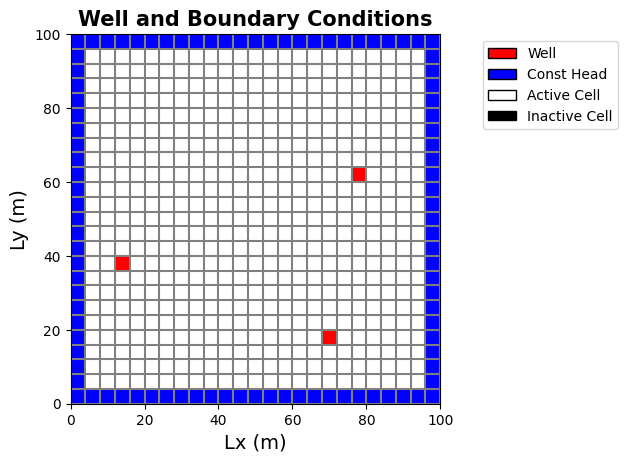

In [12]:
#CHECK WELL LOCATION
#use flopy to plot grid, ibound, and wells
modelmap = flopy.plot.PlotMapView(model=m, layer=0)
grid = modelmap.plot_grid()
ib = modelmap.plot_ibound()
wel = modelmap.plot_bc(ftype='WEL')
#add labels and legend
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Well and Boundary Conditions', fontsize = 15, fontweight = 'bold')
plt.legend(handles=[mp.patches.Patch(color='red',label='Well',ec='black'),
                   mp.patches.Patch(color='blue',label='Const Head',ec='black'),
                   mp.patches.Patch(color='white',label='Active Cell',ec='black'),
                   mp.patches.Patch(color='black',label='Inactive Cell',ec='black')],
                   bbox_to_anchor=(1.5,1.0))
plt.show(modelmap)

 <a name="VI"></a>
### VI. Specify Data Output and Attach OC Package

In [13]:
#create oc stress period data. 
spd = {(0, 0): ['print head', 'print budget', 'save head', 'save budget']}

#create flopy output control object
oc = flopy.modflow.ModflowOc(model=m, stress_period_data=spd, compact=True)

<a name="VII"></a>
### VII. Assign PCG as Finite Difference Solver and Attach PCG Package

In [14]:
#assign groundwater flow solver
pcg = flopy.modflow.ModflowPcg(model=m)

 <a name="VIII"></a>
### VIII. Create MODFLOW files and Run Model

In [15]:
#write MODFLOW input files
m.write_input()

In [16]:
# Run the model
success, mfoutput = m.run_model(pause=False, report=True)
if not success:
    raise Exception('MODFLOW did not terminate normally.')

FloPy is using the following executable to run the model: mf2005.exe

                                  MODFLOW-2005     
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUND-WATER FLOW MODEL
                             Version 1.12.00 2/3/2017                        

 Using NAME file: my_pumping_model.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2026/09/02 16:14:44

 Solving:  Stress period:     1    Time step:     1    Ground-Water Flow Eqn.
 Run end date and time (yyyy/mm/dd hh:mm:ss): 2026/09/02 16:14:44
 Elapsed run time:  0.019 Seconds

  Normal termination of simulation


<a name="IX"></a>
### IX. Extract Head and Flow Data 

In [17]:
#extract binary data from head file
headobj = flopy.utils.binaryfile.HeadFile(modelname+'.hds')
head = headobj.get_data(totim=1.0)

In [18]:
#extract binary data from budget file
budgobj = flopy.utils.binaryfile.CellBudgetFile(modelname+'.cbc')
frf = budgobj.get_data(text='flow right face', totim=1.0)
fff = budgobj.get_data(text='flow front face', totim=1.0)

<a name="X"></a>
## X. Plotting

### Head Contour and Flow Plot 

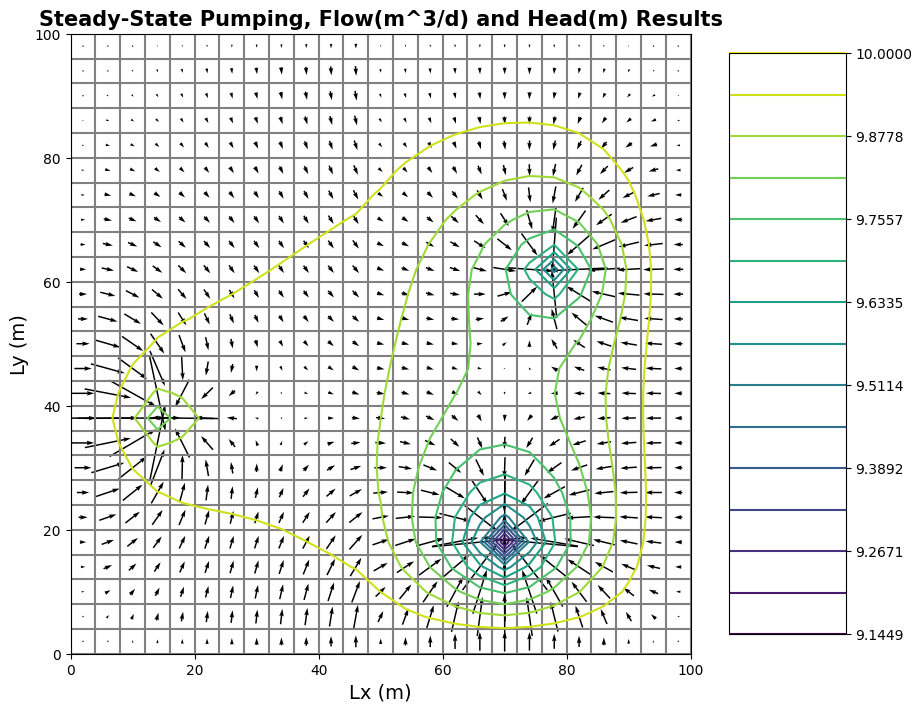

In [19]:
#plot results
plt.figure(figsize=(10,10)) #create 10 x 10 figure
modelmap = flopy.plot.PlotMapView(model=m, layer=0) #use modelmap to attach plot to model
grid = modelmap.plot_grid() #plot model grid
contour_levels = np.linspace(head[0].min(),head[0].max(),15) #set contour levels for contouring head
head_contours = modelmap.contour_array(head, levels=contour_levels) #create head contours
#flows = modelmap.plot_discharge(frf[0], fff[0], head=head) #create discharge arrows
flows=flopy.utils.postprocessing.get_specific_discharge(vectors=[frf[0], fff[0]], model=m, head=head)
arrows=modelmap.plot_vector(flows[0], flows[1])

#display parameters
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Steady-State Pumping, Flow(m^3/d) and Head(m) Results', fontsize = 15, fontweight = 'bold')
plt.colorbar(head_contours, aspect=5)
plt.show(modelmap)



### Head Contour Plot

The aquifer head may be more easily visualized with a filled contour plot using matplotlib's contourf() function.


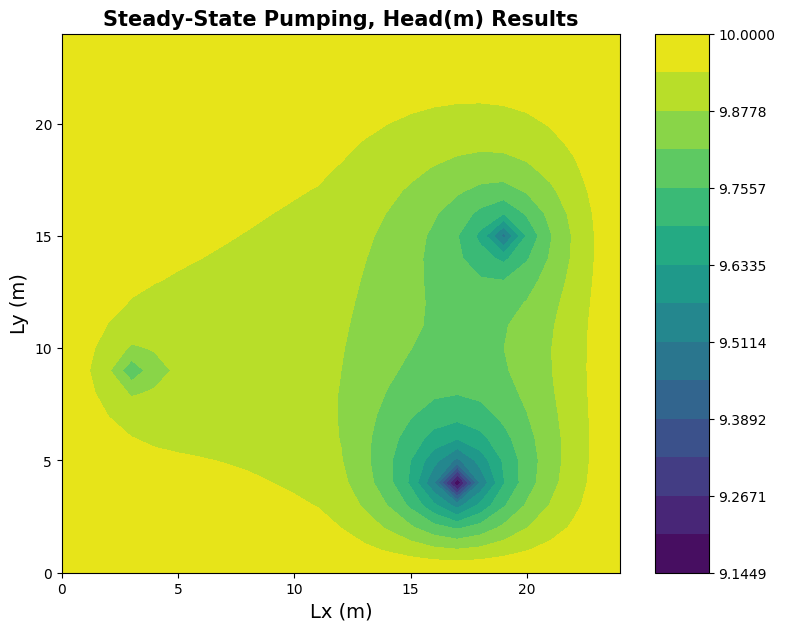

In [20]:
#create plot
plt.figure(figsize=(9,7))
cf = plt.contourf(np.flipud(head[0,:,:]),levels=contour_levels)
#display parameters
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Steady-State Pumping, Head(m) Results', fontsize = 15, fontweight = 'bold')
plt.colorbar(cf,aspect=10)
plt.show()

### 3D Head Surface Plot

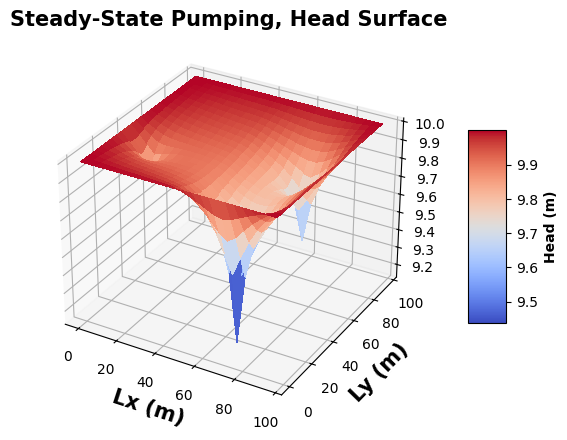

In [21]:
#import 3d axes toolkit from matplotlib
from mpl_toolkits.mplot3d import Axes3D

#create 3d figure
fig_3d = plt.figure(figsize=(12,5))
#ax = fig_3d.gca(projection='3d')
ax = fig_3d.add_subplot(projection='3d')

#set X, Y, Z variables for 3d plot to be our model domain and head solution
X = np.arange(0,Lx,dx)
Y = np.arange(0,Ly,dy)
X, Y = np.meshgrid(X, Y)
Z = np.flipud(head[0])

#create surface and labels
surf = ax.plot_surface(X,Y,Z, cmap = plt.cm.coolwarm, linewidth=0, antialiased=False, label='head')
fig_3d.colorbar(surf,shrink=0.5,aspect=5).set_label('Head (m)',fontsize=10,fontweight='bold')
ax.set_xlabel('Lx (m)', fontsize=15, fontweight='bold')
ax.set_ylabel('Ly (m)', fontsize=15, fontweight='bold')
ax.set_title('Steady-State Pumping, Head Surface', fontsize=15, fontweight='bold')
plt.show(surf)

### Head Transect Plot

It may also be helpful to visualize the head profile along a single row. Below the head head data is extracted halfway up Ly and plotted across Lx.

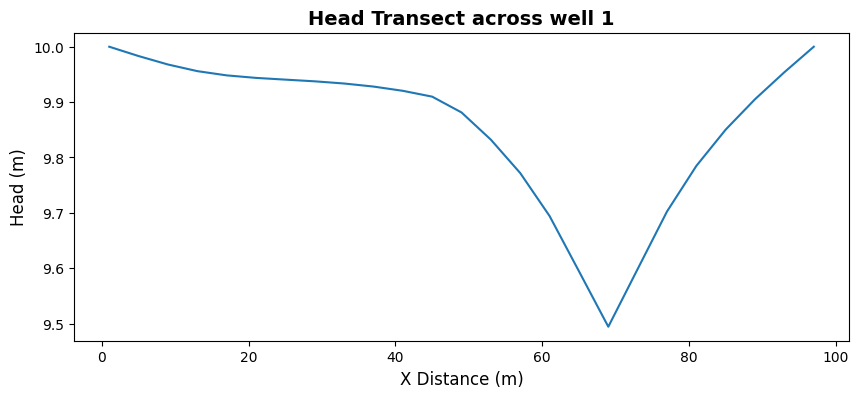

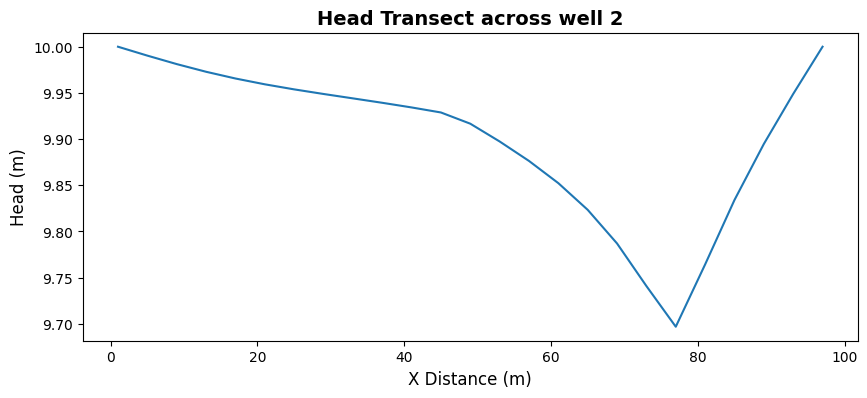

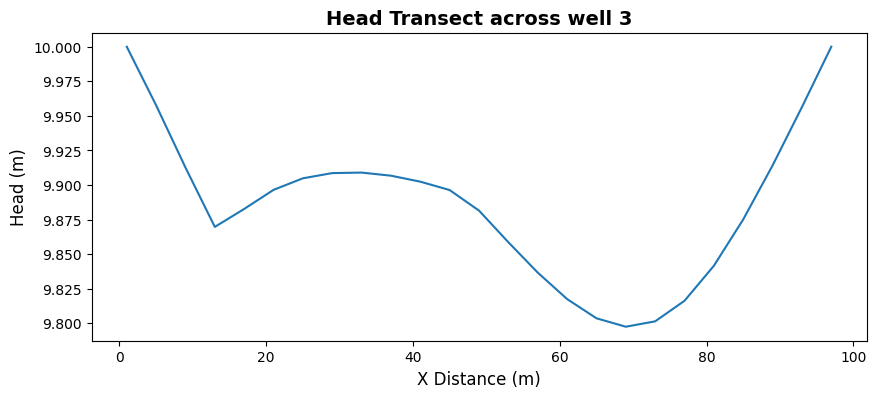

In [22]:
#plot head head transect
plt.figure(figsize = (10,4))
x = np.arange(1,Lx,dx)
plt.plot(x,np.flipud(head[0])[int(nrow-rowwell_1)][:])
plt.title('Head Transect across well 1',fontweight = 'bold', fontsize = 14)
plt.xlabel('X Distance (m)',fontsize = 12)
plt.ylabel('Head (m)',fontsize = 12)
plt.show()

#plot head head transect
plt.figure(figsize = (10,4))
x = np.arange(1,Lx,dx)
plt.plot(x,np.flipud(head[0])[int(nrow-rowwell_2)][:])
plt.title('Head Transect across well 2',fontweight = 'bold', fontsize = 14)
plt.xlabel('X Distance (m)',fontsize = 12)
plt.ylabel('Head (m)',fontsize = 12)
plt.show()

#plot head head transect
plt.figure(figsize = (10,4))
x = np.arange(1,Lx,dx)
plt.plot(x,np.flipud(head[0])[int(nrow-rowwell_3)][:])
plt.title('Head Transect across well 3',fontweight = 'bold', fontsize = 14)
plt.xlabel('X Distance (m)',fontsize = 12)
plt.ylabel('Head (m)',fontsize = 12)
plt.show()

<strong> Activities: </strong> 
- Increase pumping rates and observe the changes in head surface/drawdown extent.
- Add another pumping well variable, well_2, to the well package and rerun the model with two wells.
- Change the location of well_1 and observe different interactions with the constant head boundary conditions.
- Change the IBOUND to accomodate active flux boundaries on the top and bottom of the model edges and observe differences in head surface symmetry.

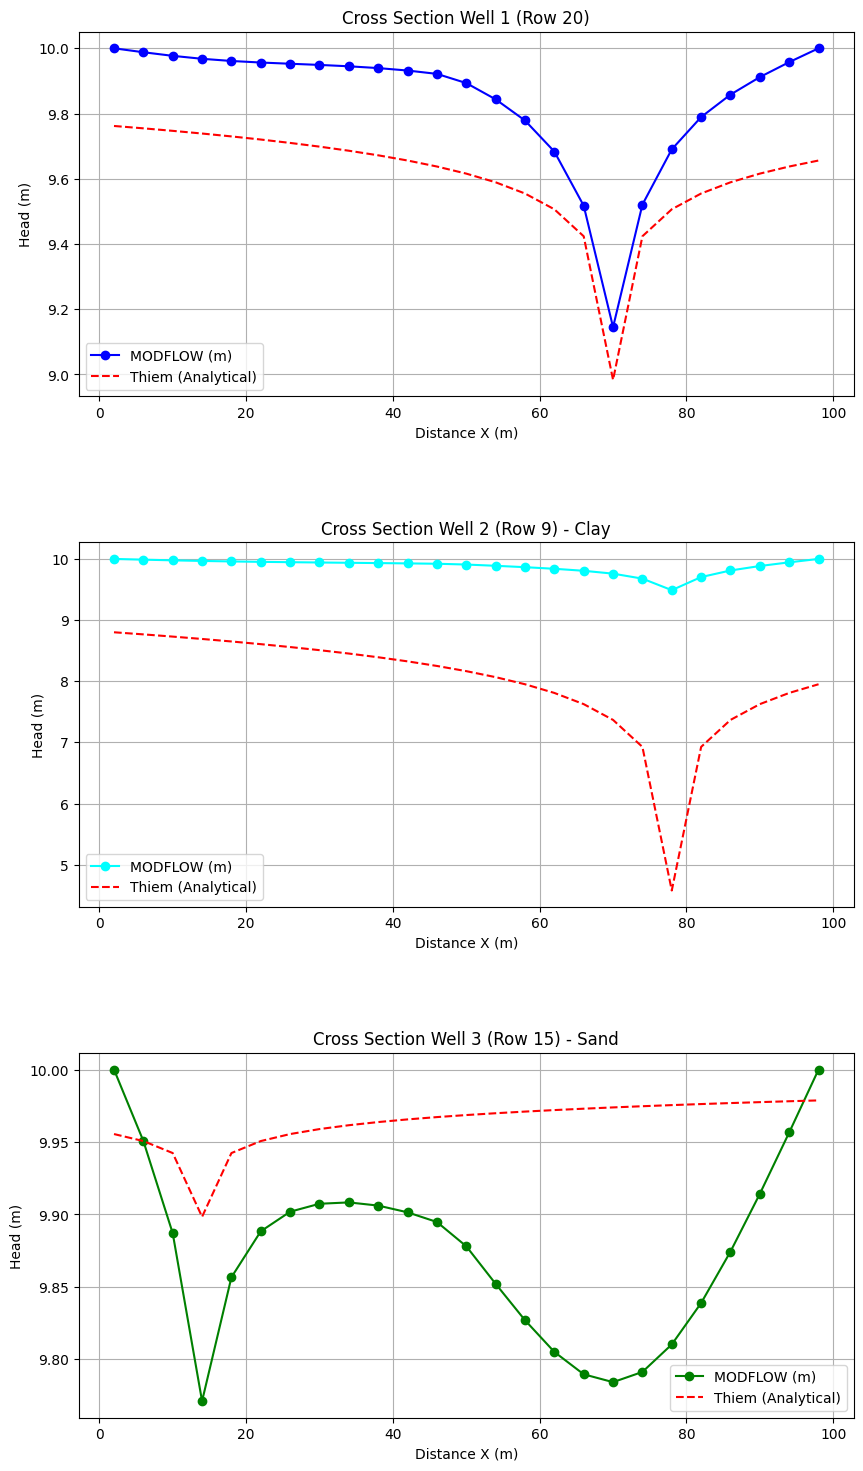

In [23]:

headobj = flopy.utils.HeadFile(modelname + '.hds')
head = headobj.get_data(totim=1.0)
x_centers = m.modelgrid.xcellcenters
x_dist = m.modelgrid.xcellcenters[0, :] # Coordinata X per il grafico
# Graphs initiation
# Creationa a figure with 3 graphs 
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 18))
plt.subplots_adjust(hspace=0.4) # Spazio tra i grafici
# GRAPH 1: WELL 1 (Row 20, Col 17)
row_w1 = 20
col_w1 = 17
Q1 = 75.0      # Streamflow Well 1
K1 = 10.0   
well_x1 = x_centers[row_w1, col_w1]
# 1. Numerical
h_num_1 = head[0, row_w1, :]
# 2. Analytical
r_array1 = abs(x_dist - well_x1)
r_array1[r_array1==0] = 0.1 # Not to divide by 0
h_an_1 = 10.0 - (Q1 / (2 * np.pi * K1 * 10)) * np.log(500 / r_array1)
# Plot 1
ax1.plot(x_dist, h_num_1, 'o-', color='blue', label='MODFLOW (m)')
ax1.plot(x_dist, h_an_1, '--', color='red', label='Thiem (Analytical)')
ax1.set_title(f"Cross Section Well 1 (Row {row_w1})")
ax1.set_ylabel("Head (m)")
ax1.set_xlabel("Distance X (m)")
ax1.legend()
ax1.grid()
# GRAPH 2: WELL 2 (Row 9, Col 19)
row_w2 = 9
col_w2 = 19
Q2 = 40.0      # Streamflow Well 2
K2 = 1.0     
well_x2 = x_centers[row_w2, col_w2]
# 1. Numerical
h_num_2 = head[0, row_w2, :]
# 2. Analytical
r_array2 = abs(x_dist - well_x2)
r_array2[r_array2==0] = 0.1
h_an_2 = 10.0 - (Q2 / (2 * np.pi * K2 * 10)) * np.log(500 / r_array2)
# Plot 2
ax2.plot(x_dist, h_num_2, 'o-', color='cyan', label='MODFLOW (m)')
ax2.plot(x_dist, h_an_2, '--', color='red', label='Thiem (Analytical)')
ax2.set_title(f"Cross Section Well 2 (Row {row_w2}) - Clay")
ax2.set_ylabel("Head (m)")
ax2.set_xlabel("Distance X (m)")
ax2.legend()
ax2.grid()
# GRAPH 3: WELL 3 (Row 15, Col 3)
row_w3 = 15
col_w3 = 3
Q3 = 15.0      # Streamflow Well 3
K3 = 20.0   
well_x3 = x_centers[row_w3, col_w3]
# 1. Numerical
h_num_3 = head[0, row_w3, :]
# 2. Analytical
r_array3 = abs(x_dist - well_x3)
r_array3[r_array3==0] = 0.1
h_an_3 = 10.0 - (Q3 / (2 * np.pi * K3 * 10)) * np.log(500 / r_array3)
# Plot 3
ax3.plot(x_dist, h_num_3, 'o-', color='green', label='MODFLOW (m)')
ax3.plot(x_dist, h_an_3, '--', color='red', label='Thiem (Analytical)')
ax3.set_title(f"Cross Section Well 3 (Row {row_w3}) - Sand")
ax3.set_xlabel("Distance X (m)")
ax3.set_ylabel("Head (m)")
ax3.legend()
ax3.grid()

plt.show()

Running sensitivity analysis...

--- Absolute Results (Head) ---


C:\Users\gieki\AppData\Local\Programs\Python\Python313\Lib\site-packages\flopy\mbase.py:622: UserWarning: Unit 15 of package LPF already in use.
  warn(
C:\Users\gieki\AppData\Local\Programs\Python\Python313\Lib\site-packages\flopy\mbase.py:631: UserWarning: Two packages of the same type, Replacing existing 'LPF' package.
  warn(
C:\Users\gieki\AppData\Local\Programs\Python\Python313\Lib\site-packages\flopy\mbase.py:622: UserWarning: Unit 20 of package WEL already in use.
  warn(
C:\Users\gieki\AppData\Local\Programs\Python\Python313\Lib\site-packages\flopy\mbase.py:631: UserWarning: Two packages of the same type, Replacing existing 'WEL' package.
  warn(


,Head Well 1 (m),Head Well 2 (m),Head Well 3 (m)
Scenario,,,
Base Case,9.14,9.49,9.77
High K (+50%),9.43,9.66,9.85
Low K (-50%),8.29,8.98,9.54
High Q (+20%),8.97,9.39,9.73
Low Q (-20%),9.32,9.59,9.82



--- Variation from Base Case (Meters) ---


,Head Well 1 (m),Head Well 2 (m),Head Well 3 (m)
Scenario,,,
Base Case,0.00,0.00,0.00
High K (+50%),0.29,0.17,0.08
Low K (-50%),-0.86,-0.51,-0.23
High Q (+20%),-0.17,-0.10,-0.05
Low Q (-20%),0.17,0.10,0.05


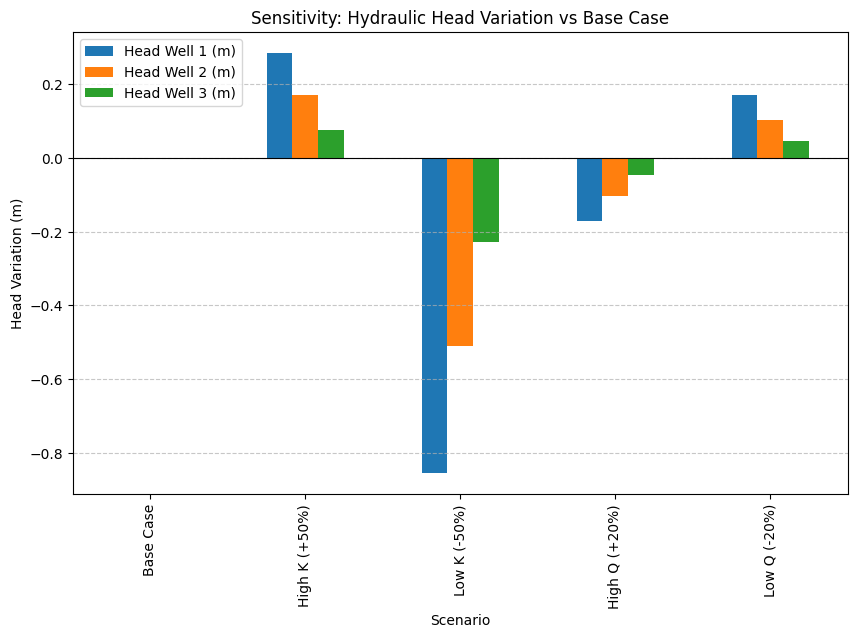

In [24]:
#Sensitivity Analysis 
import pandas as pd

# Define the variation scenarios
# 'k_mult': multiplier for Hydraulic Conductivity
# 'q_mult': multiplier for Pumping Rates
scenarios = {
    "Base Case": {'k_mult': 1.0, 'q_mult': 1.0},
    "High K (+50%)": {'k_mult': 1.5, 'q_mult': 1.0},
    "Low K (-50%)": {'k_mult': 0.5, 'q_mult': 1.0},
    "High Q (+20%)": {'k_mult': 1.0, 'q_mult': 1.2},
    "Low Q (-20%)": {'k_mult': 1.0, 'q_mult': 0.8}
}

results = []

print("Running sensitivity analysis...")

for name, params in scenarios.items():
    # 1. Modify Hydraulic Conductivity (HK)
    # Note: hk is the matrix defined in previous notebook cells
    new_hk = hk * params['k_mult']
    
    # Recreate the LPF package with the new HK
    # Using 'vka', 'ss', 'laytyp' defined previously in the notebook
    lpf = flopy.modflow.ModflowLpf(model=m, hk=new_hk, vka=vk, ss=ss, laytyp=laytyp, ipakcb=1)
    
    # 2. Modify Pumping Rates (Q)
    # Reconstruct well data with new rates
    # Using rowwell_X, colwell_X, pumping_rate_X variables defined previously
    new_wel_spd = {0: [
        [0, rowwell_1, colwell_1, pumping_rate_1 * params['q_mult']],
        [0, rowwell_2, colwell_2, pumping_rate_2 * params['q_mult']],
        [0, rowwell_3, colwell_3, pumping_rate_3 * params['q_mult']]
    ]}
    
    # Recreate the WEL package
    wel = flopy.modflow.ModflowWel(model=m, stress_period_data=new_wel_spd)
    
    # 3. Write and Run the model
    # 'silent=True' hides detailed MODFLOW output for cleanliness
    m.write_input()
    success, buff = m.run_model(silent=True)
    
    if success:
        # 4. Extract Results (Head in the 3 wells)
        headobj = flopy.utils.binaryfile.HeadFile(modelname+'.hds')
        h = headobj.get_data(totim=1.0)
        
        # Head at wells (Layer 0)
        h_w1 = h[0, rowwell_1, colwell_1]
        h_w2 = h[0, rowwell_2, colwell_2]
        h_w3 = h[0, rowwell_3, colwell_3]
        
        results.append({
            "Scenario": name,
            "Head Well 1 (m)": h_w1,
            "Head Well 2 (m)": h_w2,
            "Head Well 3 (m)": h_w3
        })

# Create a DataFrame to visualize results clearly
df_results = pd.DataFrame(results)
df_results.set_index("Scenario", inplace=True)

# Calculate difference relative to Base Case
base_heads = df_results.loc["Base Case"]
df_diff = df_results - base_heads

print("\n--- Absolute Results (Head) ---")
display(df_results.round(2))

print("\n--- Variation from Base Case (Meters) ---")
display(df_diff.round(2))

# Quick plot of differences
df_diff.plot(kind='bar', figsize=(10, 6))
plt.title("Sensitivity: Hydraulic Head Variation vs Base Case")
plt.ylabel("Head Variation (m)")
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()